In [1]:
import numpy as np
np.float = float
np.int = int 
import nanonispy2 as nap2
import nanonispy
import nanonispyfit 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 
import pickle 
import cv2 
import argparse


from skimage.color import rgb2gray, label2rgb
from skimage.feature import blob_log, peak_local_max
from skimage import exposure, filters
from skimage.util import img_as_float
from skimage.morphology import erosion, dilation, opening, closing, disk, square, white_tophat
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border, watershed
from skimage.measure import label, regionprops, find_contours
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)
from skimage import img_as_float
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio


from scipy import misc # denoising the imaage 
from scipy import ndimage as ndi

from PIL import Image

import tensorflow as tf 
from tensorflow import keras 


C:\Users\andre\AppData\Local\Temp\ipykernel_28104\784959036.py:34: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc # denoising the imaage


In [2]:
def CCL(im, plot=True):
    """
    Uses Connected Component Labels to make the molecules more clear 
    Args: 
        im: The image to be implemented, binary and gray scale
    Returns: 
        gray: The image after CCL is applied 
        coutour_img: The image containing contours 
        NUM_MOL: Total number of molecules
    """
    
    
    im_norm = cv2.normalize(im, None, 0, 255, cv2.NORM_MINMAX)
    im_uint8 = im_norm.astype(np.uint8)
    
   # Otsu threshold
    _, binary = cv2.threshold(im_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary_01 = (binary > 0).astype(np.uint8)
    
    (numLabels, Labels, stats, centroids) = cv2.connectedComponentsWithStats(binary_01, 4, cv2.CV_32S)


    # Assign random colors to each component (background = black)
    output = np.zeros((Labels.shape[0], Labels.shape[1], 3), dtype=np.uint8)
    colors = np.random.randint(0, 255, size=(numLabels, 3), dtype=np.uint8)
    for i in range(1, numLabels):  # skip background
        output[Labels == i] = colors[i]
    
    gray = cv2.cvtColor(output, cv2.COLOR_BGR2GRAY)
    
    if plot:
        # Plotting 
        gray = cv2.cvtColor(output, cv2.COLOR_BGR2GRAY)

        # Threshold (to get binary image)
        _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

        # Find contours
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Draw contours on a copy of original image
        NUM_MOL = len(contours)
        contour_img = output.copy()
        cv2.drawContours(contour_img, contours, -1, (0, 0, 255), 4)  

        # Show
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
        plt.title(f'CCL;Number of Molucules: {NUM_MOL}')
        plt.axis("off")
        plt.show()
    
    
    return gray, contour_img, NUM_MOL
    


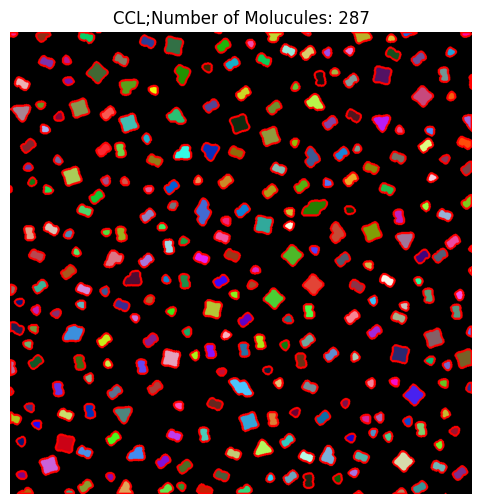

(1024, 1024)

In [4]:
scan = nanonispy.read.Scan('Stetsovych Helicene/Helicene_Ag(111)008.sxm')
im = scan.signals["Z"]["backward"]
orig_im = im 

im = nanonispyfit.plane_fit_2d(im)
im = cv2.normalize(im, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

gray, contour_img, NUM_MOL = CCL(im) # Use gray for modelling

contour_img = cv2.cvtColor(contour_img, cv2.COLOR_BGR2GRAY)
contour_img.shape